# BT4012 Kaggle Group 10: Health Insurance Fraud Detection
**Author:** (e1122416), Quek Ying Han Clare (e1156061), Eunice Gong Shi Min (e1155847)  
**Course:** BT4012  
**Institution:** National University of Singapore  
**Date:** November 2025

## Project Overview

This notebook presents a comprehensive approach to healthcare provider fraud detection using machine learning techniques. The goal is to classify healthcare providers as either fraudulent or non-fraudulent based on claims, beneficiary, and provider data.

**Dataset Context:**
- **Training data**: Historical claims, provider information, and beneficiary details with fraud labels  
- **Test data**: Unlabeled provider or claim records requiring fraud prediction  
- **Target variable**: Binary (0 = Non-Fraudulent, 1 = Fraudulent)  
- **Evaluation metric**: ROC AUC (Area Under the Curve), Precision, Recall, and F1-Score  

**Key Features:**
- Provider demographic and specialty information  
- Claims data (inpatient/outpatient claims, claim amounts, procedure codes)  
- Beneficiary information (age, gender, chronic conditions, number of visits)  
- Aggregated statistics per provider (average claim amount, claim frequency, diagnosis/procedure diversity)  

**Project Goals:**
1. Perform exploratory data analysis (EDA) to understand patterns and detect anomalies in claims and provider behavior.  
2. Engineer meaningful features to capture provider behavior trends and risk factors.  
3. Train and evaluate supervised machine learning models (e.g., Logistic Regression, Random Forest, XGBoost) to predict provider fraud.  
4. Implement interpretability techniques (e.g., SHAP values) to identify key features driving fraud predictions.  
5. Explore anomaly detection and unsupervised approaches to detect potential fraud not labeled in the dataset.  
6. Provide actionable insights for healthcare providers and insurers to mitigate fraudulent activities.

## Computational Dependencies & Dependencies

In [8]:
# Data manipulation
import numpy as np
import pandas as pd

# Machine learning models and preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from tqdm import tqdm
import joblib
from pathlib import Path


## Load Datasets

In [11]:
beneficiary_train = pd.read_csv("data/Train_Beneficiarydata-1542865627584.csv")
inpatient_train = pd.read_csv("data/Train_Inpatientdata-1542865627584.csv")
outpatient_train = pd.read_csv("data/Train_Outpatientdata-1542865627584.csv")
provider_train = pd.read_csv("data/Train-1542865627584.csv")

print("Beneficiary Data Shape:", beneficiary_train.shape)
print("Inpatient Data Shape:", inpatient_train.shape)
print("Outpatient Data Shape:", outpatient_train.shape)
print("Provider Data Shape:", provider_train.shape)

print(f"Dataset loaded successfully with {beneficiary_train.shape[0]} beneficiaries, {inpatient_train.shape[0]} inpatients, {outpatient_train.shape[0]} outpatients, and {provider_train.shape[0]} providers.")

Beneficiary Data Shape: (138556, 25)
Inpatient Data Shape: (40474, 30)
Outpatient Data Shape: (517737, 27)
Provider Data Shape: (5410, 2)
Dataset loaded successfully with 138556 beneficiaries, 40474 inpatients, 517737 outpatients, and 5410 providers.


In [12]:
beneficiary_test = pd.read_csv("data/Test_Beneficiarydata-1542969243754.csv")
inpatient_test = pd.read_csv("data/Test_Inpatientdata-1542969243754.csv")
outpatient_test = pd.read_csv("data/Test_Outpatientdata-1542969243754.csv")
provider_test = pd.read_csv("data/Test-1542969243754.csv")

print("Beneficiary Data Shape:", beneficiary_test.shape)
print("Inpatient Data Shape:", inpatient_test.shape)
print("Outpatient Data Shape:", outpatient_test.shape)
print("Provider Data Shape:", provider_test.shape)

print(f"Dataset loaded successfully with {beneficiary_test.shape[0]} beneficiaries, {inpatient_test.shape[0]} inpatients, {outpatient_test.shape[0]} outpatients, and {provider_test.shape[0]} providers.")

Beneficiary Data Shape: (63968, 25)
Inpatient Data Shape: (9551, 30)
Outpatient Data Shape: (125841, 27)
Provider Data Shape: (1353, 1)
Dataset loaded successfully with 63968 beneficiaries, 9551 inpatients, 125841 outpatients, and 1353 providers.


## Data Cleaning and EDA
**1. Read and Understand the Raw Data**

**2. EDA on Raw Data**
- Distribution of numerical variables (histograms, boxplots).
- Categories and their frequencies.
- Correlations and relationships between features.
- Missing data patterns.
- Potential data entry errors or inconsistencies.

**3. Clean Data**
- Handle missing values (impute, fill, or drop).
- Fix datatypes (e.g., convert strings to dates or numbers).
- Remove or handle outliers.
- Standardize text fields (e.g., casing, trimming whitespace).
- Fix inconsistent categories.
- Handle duplicates.
- Normalize or scale numerical data (if needed for modeling).

**4. EDA on Cleaned Data**
- Re-run descriptive stats and plots to confirm issues are resolved.
- Verify data integrity (no missing/invalid values left, distributions make sense).
- Explore features more deeply for model-building (feature engineering ideas, correlations, etc.).


## Read and Understand the Raw Data
### Taken from Kaggle
**A) Inpatient Data**

This data provides insights about the claims filed for those patients who are admitted in the hospitals. It also provides additional details like their admission and discharge dates and admit d diagnosis code.

**B) Outpatient Data**

This data provides details about the claims filed for those patients who visit hospitals and not admitted in it.

**C) Beneficiary Details Data**

This data contains beneficiary KYC details like health conditions,regioregion they belong to etc.

In [ ]:
# 2) Helper: peek at columns & auto-detect likely date columns
def detect_date_cols(path, sample_rows=1000):
    sample = pd.read_csv(path, nrows=sample_rows, low_memory=False)
    # Heuristic: any column name that looks like a date
    candidates = [c for c in sample.columns if any(s in c.lower() for s in ["date", "dt", "dob", "dod"])]
    return sorted(set(candidates))

# (Optional) See which columns will be parsed as dates
date_cols = {
    "train":      detect_date_cols(p_train),
    "benef":      detect_date_cols(p_benef),
    "inpatient":  detect_date_cols(p_inpatient),
    "outpatient": detect_date_cols(p_outpatient),
}
print("Guessed date columns:", date_cols)

# 3) Read with good defaults
# - low_memory=False => better type inference
# - dtype_backend="pyarrow" (if pandas >= 2.0) => memory efficient + nullable dtypes
common_read_kwargs = dict(
    low_memory=False,
)
try:
    # If your pandas supports it, this helps memory use and null handling
    common_read_kwargs["dtype_backend"] = "pyarrow"
except TypeError:
    pass  # older pandas, ignore

date_parser = lambda x: pd.to_datetime(x, format="%Y-%m-%d", errors="coerce")

df_train = pd.read_csv(p_train,      parse_dates=date_cols["train"],      date_format=date_parser, **common_read_kwargs)
df_bene  = pd.read_csv(p_benef,      parse_dates=date_cols["benef"],      date_format=date_parser, **common_read_kwargs)
df_inp   = pd.read_csv(p_inpatient,  parse_dates=date_cols["inpatient"],  date_format=date_parser, **common_read_kwargs)
df_out   = pd.read_csv(p_outpatient, parse_dates=date_cols["outpatient"], date_format=date_parser, **common_read_kwargs)

# 4) Quick sanity checks / previews
for name, df in [("train", df_train), ("benef", df_bene), ("inpatient", df_inp), ("outpatient", df_out)]:
    print(f"\n== {name.upper()} ==")
    print("shape:", df.shape)
    print(df.head(3))
    print(df.dtypes.head(10))  # first 10 dtypes to keep output short



## Merge Datasets

In [13]:
print(inpatient_train.shape)
print(outpatient_train.shape)

# flag for inpatient vs outpatient
inpatient_train['admitted'] = 1
outpatient_train['admitted'] = 0
# ensure both have same columns
not_in_out = set(inpatient_train.columns) - set(outpatient_train.columns)
print(set(inpatient_train.columns) - set(outpatient_train.columns))

for col in not_in_out:
    outpatient_train[col] = pd.NA
    
print(inpatient_train.shape)
print(outpatient_train.shape)

(40474, 30)
(517737, 27)
{'DischargeDt', 'AdmissionDt', 'DiagnosisGroupCode'}
(40474, 31)
(517737, 31)


In [14]:
print(inpatient_test.shape)
print(outpatient_test.shape)

# flag for inpatient vs outpatient
inpatient_test['admitted'] = 1
outpatient_test['admitted'] = 0
# ensure both have same columns
not_in_out = set(inpatient_test.columns) - set(outpatient_test.columns)
print(set(inpatient_test.columns) - set(outpatient_test.columns))

for col in not_in_out:
    outpatient_test[col] = pd.NA
    
print(inpatient_test.shape)
print(outpatient_test.shape)

(9551, 30)
(125841, 27)
{'DischargeDt', 'AdmissionDt', 'DiagnosisGroupCode'}
(9551, 31)
(125841, 31)


In [15]:
# Claims are merged by stacking inpatient and outpatient
claims_all_train = pd.concat([inpatient_train, outpatient_train], axis=0)
claims_all_test = pd.concat([inpatient_test, outpatient_test], axis=0)

print(claims_all_train.shape)
print(claims_all_test.shape)
print(claims_all_train.head())
print(claims_all_test.head())

(558211, 31)
(135392, 31)
      BeneID   ClaimID ClaimStartDt  ClaimEndDt  Provider  \
0  BENE11001  CLM46614   2009-04-12  2009-04-18  PRV55912   
1  BENE11001  CLM66048   2009-08-31  2009-09-02  PRV55907   
2  BENE11001  CLM68358   2009-09-17  2009-09-20  PRV56046   
3  BENE11011  CLM38412   2009-02-14  2009-02-22  PRV52405   
4  BENE11014  CLM63689   2009-08-13  2009-08-30  PRV56614   

   InscClaimAmtReimbursed AttendingPhysician OperatingPhysician  \
0                   26000          PHY390922                NaN   
1                    5000          PHY318495          PHY318495   
2                    5000          PHY372395                NaN   
3                    5000          PHY369659          PHY392961   
4                   10000          PHY379376          PHY398258   

  OtherPhysician AdmissionDt  ... ClmDiagnosisCode_8  ClmDiagnosisCode_9  \
0            NaN  2009-04-12  ...              19889                5849   
1            NaN  2009-08-31  ...                NaN

In [16]:
# Merge claims with beneficiary and provider data
claims_bene_train = claims_all_train.merge(beneficiary_train, on='BeneID', how='left')
train = claims_bene_train.merge(provider_train, on='Provider', how='left')
train.to_csv("data/full_data_train.csv", index=False)

In [17]:
# Merge claims with beneficiary and provider data
claims_bene_test = claims_all_test.merge(beneficiary_test, on='BeneID', how='left')
test = claims_bene_test.merge(provider_test, on='Provider', how='left')
test.to_csv("data/full_data_test.csv", index=False)

## Feature Engineering

- Age_at_Claim: Age of patient when insurance claim was submitted
- Claim_Date_Mismatch: Check if AdmissionDt is after ClaimStartDt OR DischargeDt is before ClaimEndDt, highlights administrative errors or fraud because insurance claims cannot be made beyond hospitalised days
- Diagnosis/Procedure Count: Number of diagnosis/prodecures each patient underwent

In [18]:
def create_all_features(full_df, physician_stats=None):
    """
    Applies all defined feature engineering steps to the DataFrame.

    Args:
        full_df (pd.DataFrame): The main DataFrame containing claim and beneficiary data.
        physician_stats (dict, optional): Pre-calculated physician statistics from training data.
                                         Should contain 'total_claims' and 'fraud_ratios' DataFrames.
                                         If None, calculates from the input data (training mode).

    Returns:
        tuple: (pd.DataFrame, dict) - The DataFrame with all engineered features and physician stats dict
    """
    df = full_df.copy() # Work on a copy to avoid modifying the original DataFrame unexpectedly
    
    # --- I. Date Conversion (Prerequisite) ---
    date_columns = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt', 'DOB', 'DOD']
    for col in date_columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        
    # --- II. Binary Conversions ---
    # 1. PotentialFraud to Numeric (0/1)
    if 'PotentialFraud' in df.columns:
        df['PotentialFraud'] = df['PotentialFraud'].map({'Yes': 1, 'No': 0})
    
    # 2. Chronic Disease Conversion (2 to 0)
    chronic_cols = [col for col in df.columns if col.startswith('ChronicCond_')]
    df[chronic_cols] = df[chronic_cols].replace(2, 0)

    # --- III. Time and Flag Features ---
    
    # 1. Age at Claim
    df['Age_at_Claim'] = (df['ClaimStartDt'].dt.year - df['DOB'].dt.year)
    df['Age_at_Claim'] = df['Age_at_Claim'].apply(lambda x: x if x >= 0 else np.nan)
    
    # 2. Claim Date Mismatch Flag
    df['Claim_Date_Mismatch'] = np.where(
        (df['AdmissionDt'] > df['ClaimStartDt']) | (df['DischargeDt'] < df['ClaimEndDt']),
        1, 0
    )

    # --- IV. Count-based Features ---
    
    # Diagnosis and Procedure Columns
    diag_cols = [f'ClmDiagnosisCode_{i}' for i in range(1, 11)]
    proc_cols = [f'ClmProcedureCode_{i}' for i in range(1, 7)]
    
    # 1. Count of Diagnoses/Procedures (notna)
    df['Diagnosis_Count'] = df[diag_cols].notna().sum(axis=1)
    # Ensure procedure codes are treated as non-NaN only if they have a non-zero/non-NaN value
    df['Procedure_Count'] = df[proc_cols].notna().sum(axis=1)

    # 2. Procedure / Diagnosis Ratio
    EPSILON = 1e-6
    df['Proc_Diag_Ratio'] = df['Procedure_Count'] / (df['Diagnosis_Count'] + EPSILON)
    
    # --- V. Numerical Transformations and Ratios ---

    # 1. Arcsinh Transformation (for signed financial data)
    num_transform_cols = [
        'InscClaimAmtReimbursed', 'DeductibleAmtPaid',
        'IPAnnualReimbursementAmt', 'OPAnnualReimbursementAmt'
    ]
    for col in num_transform_cols:
        df[f'{col}_arcsinh'] = np.arcsinh(df[col])

    # 2. Annual Reimbursement to Deductible Ratios
    df['IP_Reimb_Deduct_Ratio'] = (
        df['IPAnnualReimbursementAmt'] / (df['IPAnnualDeductibleAmt'] + EPSILON)
    )
    df['OP_Reimb_Deduct_Ratio'] = (
        df['OPAnnualReimbursementAmt'] / (df['OPAnnualDeductibleAmt'] + EPSILON)
    )

    # --- VI. Physician Frequency and Fraud Ratios ---
    
    physician_cols = ['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician']
    
    # If physician_stats not provided, calculate from the current data (training mode)
    if physician_stats is None:
        physician_stats = {'total_claims': {}, 'fraud_ratios': {}}
        
        # Only calculate fraud stats if PotentialFraud column exists (training data)
        if 'PotentialFraud' in df.columns:
            fraud_df_temp = df[df['PotentialFraud'] == 1].copy()
        
        for col in physician_cols:
            # 1. Calculate Total Claim Count per Physician
            total_claims_count = df.groupby(col)['ClaimID'].nunique().rename(f'{col}_Total_Claims')
            physician_stats['total_claims'][col] = total_claims_count
            df = df.merge(total_claims_count, on=col, how='left')
            
            # 2. Calculate Fraud Claim Count per Physician (only if PotentialFraud exists)
            if 'PotentialFraud' in df.columns:
                fraud_claims_count = fraud_df_temp.groupby(col)['ClaimID'].nunique().rename(f'{col}_Fraud_Claims')
                df = df.merge(fraud_claims_count, on=col, how='left')
                
                # Fill NaNs (Physicians with 0 fraud claims)
                df[f'{col}_Fraud_Claims'] = df[f'{col}_Fraud_Claims'].fillna(0)
                
                # 3. Calculate Fraud Ratio
                df[f'{col}_Fraud_Ratio'] = df[f'{col}_Fraud_Claims'] / df[f'{col}_Total_Claims']
                # Replace inf/-inf (only happens if Total_Claims is NaN, which means a missing physician ID)
                df[f'{col}_Fraud_Ratio'] = df[f'{col}_Fraud_Ratio'].replace([np.inf, -np.inf], 0)
                
                # Store fraud ratio for later use on test data
                physician_stats['fraud_ratios'][col] = df.groupby(col)[f'{col}_Fraud_Ratio'].first()
            else:
                # If no PotentialFraud column, set fraud features to 0
                df[f'{col}_Fraud_Claims'] = 0
                df[f'{col}_Fraud_Ratio'] = 0
    
    else:
        # Use pre-calculated physician stats (test mode)
        for col in physician_cols:
            # Merge total claims count (even though this may differ from training, we use training stats)
            if col in physician_stats['total_claims']:
                df = df.merge(
                    physician_stats['total_claims'][col].to_frame(), 
                    on=col, 
                    how='left'
                )
            else:
                df[f'{col}_Total_Claims'] = 0
            
            # Merge fraud ratio from training data
            if col in physician_stats['fraud_ratios']:
                df = df.merge(
                    physician_stats['fraud_ratios'][col].to_frame().rename(columns={f'{col}_Fraud_Ratio': f'{col}_Fraud_Ratio'}),
                    on=col,
                    how='left'
                )
                # Fill NaN with 0 for physicians not seen in training
                df[f'{col}_Fraud_Ratio'] = df[f'{col}_Fraud_Ratio'].fillna(0)
            else:
                df[f'{col}_Fraud_Ratio'] = 0
            
            # Calculate fraud claims from ratio and total (for consistency)
            df[f'{col}_Fraud_Claims'] = df[f'{col}_Fraud_Ratio'] * df[f'{col}_Total_Claims']
        
    return df, physician_stats



### Splitting Data

In [19]:
# ============================================================================
# IMPORTANT: To avoid data leakage, we split BEFORE feature engineering
# ============================================================================

print("🔀 === SPLITTING DATA BEFORE FEATURE ENGINEERING (To Avoid Leakage) ===\n")

# First, split the raw merged data into train and validation
# This ensures validation data doesn't influence feature engineering
X_raw = train.drop(columns=['PotentialFraud']).copy()
y_raw = train['PotentialFraud'].copy()

# Perform stratified 70-30 split on RAW data
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_raw, y_raw, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_raw
)

# Recombine for feature engineering
train_split = pd.concat([X_train_raw, y_train_raw], axis=1)
val_split = pd.concat([X_val_raw, y_val_raw], axis=1)

print(f"Training split (70%): {train_split.shape[0]:,} samples")
print(f"Validation split (30%): {val_split.shape[0]:,} samples")
print(f"Training fraud ratio: {y_train_raw.value_counts()[1] / y_train_raw.value_counts()[0]:.3f}")
print(f"Validation fraud ratio: {y_val_raw.value_counts()[1] / y_val_raw.value_counts()[0]:.3f}\n")

# Apply feature engineering to training split ONLY (this learns physician stats)
print("⚙️ Applying feature engineering to TRAINING split...")
engineered_train, physician_stats = create_all_features(train_split)
print(f"✅ Training features created: {engineered_train.shape}")

# Apply feature engineering to validation split using TRAINING statistics
print("⚙️ Applying feature engineering to VALIDATION split (using training stats)...")
engineered_val, _ = create_all_features(val_split, physician_stats=physician_stats)
print(f"✅ Validation features created: {engineered_val.shape}")

# Apply to final test data using the physician statistics from training
print("⚙️ Applying feature engineering to TEST data (using training stats)...")
engineered_test, _ = create_all_features(test, physician_stats=physician_stats)
print(f"✅ Test features created: {engineered_test.shape}\n")

print("🎯 No data leakage! Validation and test sets use only training statistics.\n")

🔀 === SPLITTING DATA BEFORE FEATURE ENGINEERING (To Avoid Leakage) ===

Training split (70%): 390,747 samples
Validation split (30%): 167,464 samples
Training fraud ratio: 0.616
Validation fraud ratio: 0.616

⚙️ Applying feature engineering to TRAINING split...


/var/folders/l4/gm3zx2sj1qb4f9vn8xp6kmf80000gn/T/ipykernel_47248/2948914048.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Training fraud ratio: {y_train_raw.value_counts()[1] / y_train_raw.value_counts()[0]:.3f}")
/var/folders/l4/gm3zx2sj1qb4f9vn8xp6kmf80000gn/T/ipykernel_47248/2948914048.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Training fraud ratio: {y_train_raw.value_counts()[1] / y_train_raw.value_counts()[0]:.3f}")
/var/folders/l4/gm3zx2sj1qb4f9vn8xp6kmf80000gn/T/ipykernel_47248/2948914048.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a fu

✅ Training features created: (390747, 76)
⚙️ Applying feature engineering to VALIDATION split (using training stats)...
✅ Validation features created: (167464, 76)
⚙️ Applying feature engineering to TEST data (using training stats)...
✅ Test features created: (135392, 75)

🎯 No data leakage! Validation and test sets use only training statistics.



In [20]:
# Checking for data imbalance in TRAINING split only
fraud_to_nonfraud_ratio = engineered_train['PotentialFraud'].value_counts(normalize=True)
print("📊 Class distribution in TRAINING split:")
print(fraud_to_nonfraud_ratio)

# DataFrame for Fraudulent Claims (PotentialFraud = 1)
fraud_train = engineered_train[engineered_train['PotentialFraud'] == 1].copy()

# DataFrame for Non-Fraudulent Claims (PotentialFraud = 0)
non_fraud_train = engineered_train[engineered_train['PotentialFraud'] == 0].copy()

print(f"\nFraud Claims Count: {len(fraud_train)}") 
print(f"Non-Fraud Claims Count: {len(non_fraud_train)}")

📊 Class distribution in TRAINING split:
PotentialFraud
0    0.618789
1    0.381211
Name: proportion, dtype: float64

Fraud Claims Count: 148957
Non-Fraud Claims Count: 241790


--- Overall Claim Code Analysis ---


/var/folders/l4/gm3zx2sj1qb4f9vn8xp6kmf80000gn/T/ipykernel_47248/126904680.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.index, y=top_n.values, palette="viridis")


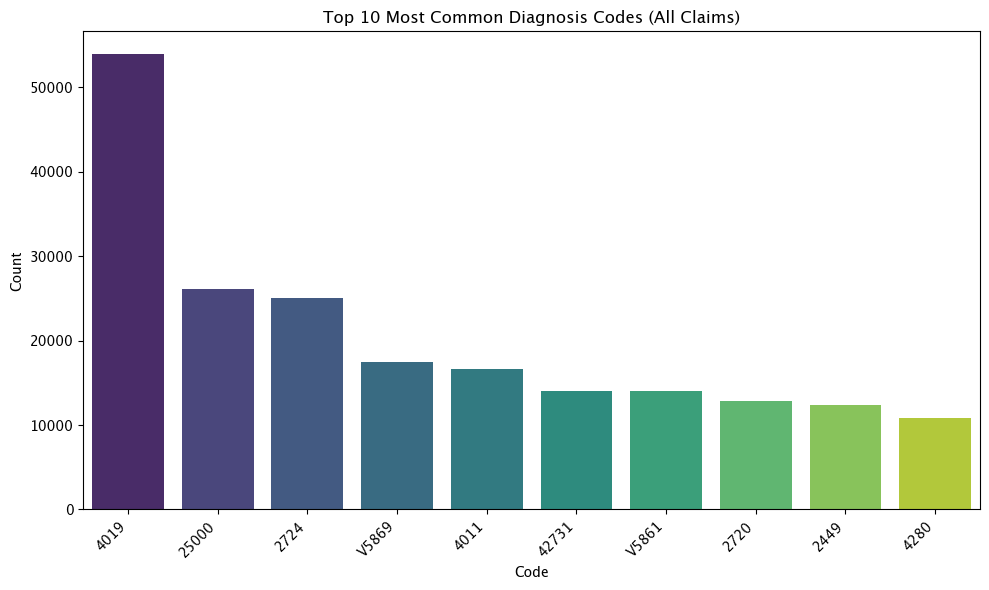

/var/folders/l4/gm3zx2sj1qb4f9vn8xp6kmf80000gn/T/ipykernel_47248/126904680.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_n.index, y=top_n.values, palette="viridis")


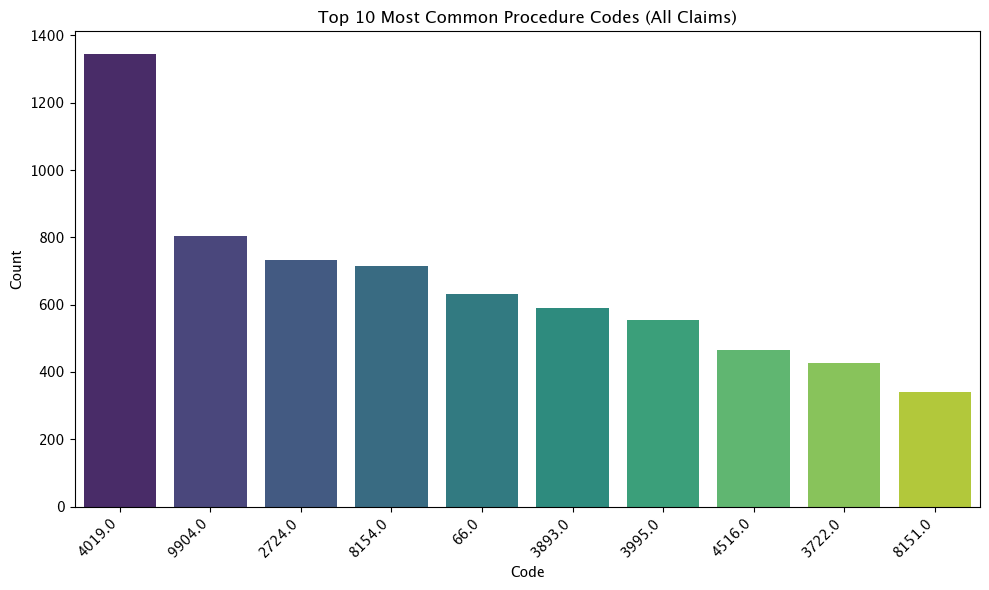


--- Fraud vs. Non-Fraud Comparison Analysis ---


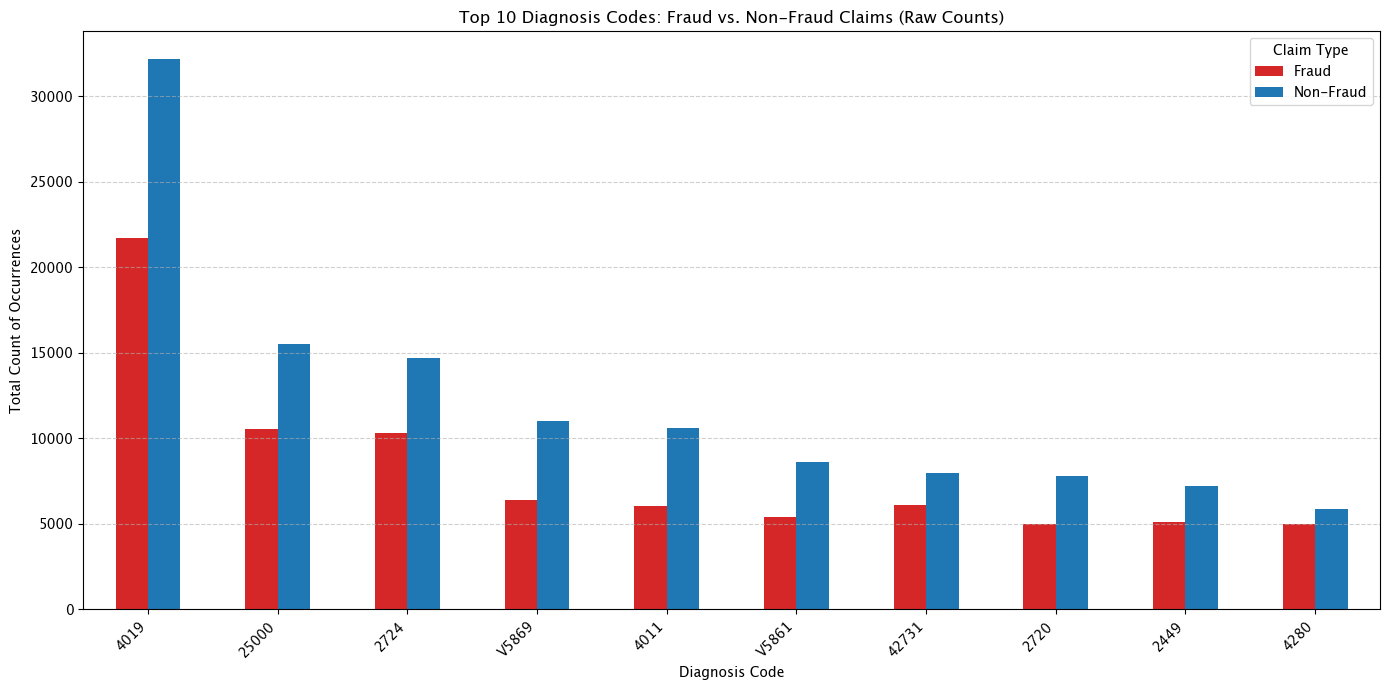

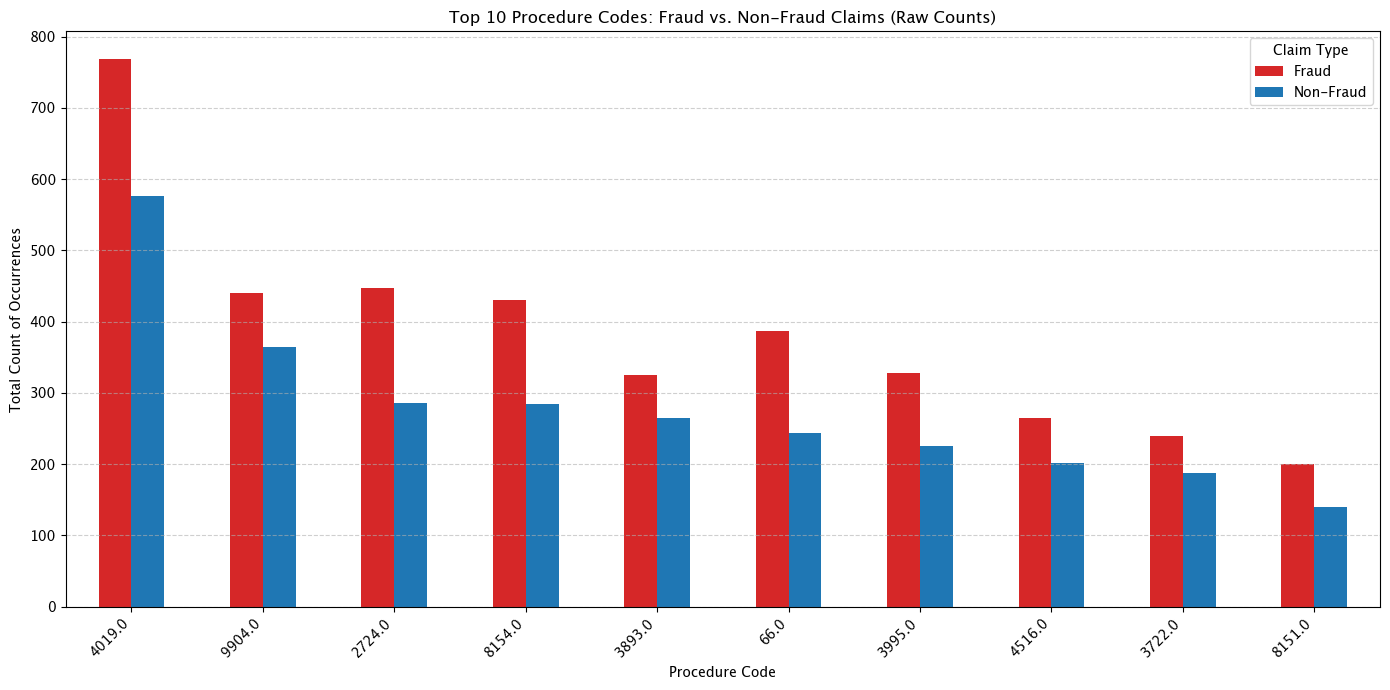

In [21]:
diagnosis_cols = [f'ClmDiagnosisCode_{i}' for i in range(1, 11)]

# Procedure codes run from 1 to 6
procedure_cols = [f'ClmProcedureCode_{i}' for i in range(1, 7)]

def plot_top_n_codes(df, code_cols, title, n=10):
    """Stacks code columns, counts occurrences, and plots the top N."""
    
    # Apply astype(str) to handle mixed types (important for Procedure Codes which are float/int/nan)
    all_codes = df[code_cols].astype(str).stack().value_counts()
    
    # Filter out NaNs if any were converted to 'nan' string
    all_codes = all_codes[all_codes.index != 'nan']
    
    # Select the top N
    top_n = all_codes.head(n)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_n.index, y=top_n.values, palette="viridis")
    plt.title(f'Top {n} Most Common {title}')
    plt.xlabel('Code')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def get_comparison_counts(df, code_list):
    """Stacks and counts all codes, filtering for a specific list of codes."""
    # Apply astype(str) and stack
    counts = df[code_list].astype(str).stack().value_counts()
    # Filter out NaNs
    counts = counts[counts.index != 'nan']
    return counts


# --- 3. Execution: Individual Plots (Overall Diagnosis and Procedure) ---

print("--- Overall Claim Code Analysis ---")
# 1. ALL Claims Diagnosis
plot_top_n_codes(engineered_train, diagnosis_cols, 'Diagnosis Codes (All Claims)')

# 2. ALL Claims Procedure
plot_top_n_codes(engineered_train, procedure_cols, 'Procedure Codes (All Claims)')


# --- 4. Execution: Fraud vs. Non-Fraud Comparison Plots ---

print("\n--- Fraud vs. Non-Fraud Comparison Analysis ---")

# --- A. Diagnosis Code Comparison ---

# 1. Determine the top 10 most frequent diagnosis codes across ALL claims
all_diag_counts = get_comparison_counts(engineered_train, diagnosis_cols)
top_10_diag_codes = all_diag_counts.head(10).index

# 2. Get counts for the top 10 codes in both groups, re-indexing to ensure common codes
fraud_diag_counts = get_comparison_counts(fraud_train, diagnosis_cols).reindex(top_10_diag_codes, fill_value=0).rename('Fraud')
non_fraud_diag_counts = get_comparison_counts(non_fraud_train, diagnosis_cols).reindex(top_10_diag_codes, fill_value=0).rename('Non-Fraud')

# 3. Combine and sort
diag_plot_df = pd.concat([fraud_diag_counts, non_fraud_diag_counts], axis=1)
diag_plot_df.index.name = 'Diagnosis_Code'
# Sort by Non-Fraud count for typical representation (since Non-Fraud is the largest group)
diag_plot_df = diag_plot_df.sort_values(by='Non-Fraud', ascending=False)

# 4. Plotting Diagnosis results
diag_plot_df.plot(kind='bar', figsize=(14, 7), color=['tab:red', 'tab:blue'])
plt.title('Top 10 Diagnosis Codes: Fraud vs. Non-Fraud Claims (Raw Counts)')
plt.xlabel('Diagnosis Code')
plt.ylabel('Total Count of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Claim Type')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- B. Procedure Code Comparison ---

# 1. Determine the top 10 most frequent procedure codes across ALL claims
all_proc_counts = get_comparison_counts(engineered_train, procedure_cols)
top_10_proc_codes = all_proc_counts.head(10).index

# 2. Get counts for the top 10 codes in both groups, re-indexing to ensure common codes
fraud_proc_counts = get_comparison_counts(fraud_train, procedure_cols).reindex(top_10_proc_codes, fill_value=0).rename('Fraud')
non_fraud_proc_counts = get_comparison_counts(non_fraud_train, procedure_cols).reindex(top_10_proc_codes, fill_value=0).rename('Non-Fraud')

# 3. Combine and sort
proc_plot_df = pd.concat([fraud_proc_counts, non_fraud_proc_counts], axis=1)
proc_plot_df.index.name = 'Procedure_Code'
proc_plot_df = proc_plot_df.sort_values(by='Non-Fraud', ascending=False) 

# 4. Plotting Procedure results
proc_plot_df.plot(kind='bar', figsize=(14, 7), color=['tab:red', 'tab:blue'])
plt.title('Top 10 Procedure Codes: Fraud vs. Non-Fraud Claims (Raw Counts)')
plt.xlabel('Procedure Code')
plt.ylabel('Total Count of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Claim Type')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [22]:
# Save engineered datasets (optional - for later use)
print("💾 Saving engineered datasets...")
engineered_train.to_csv("data/engineered_train_split.csv", index=False)
engineered_val.to_csv("data/engineered_val_split.csv", index=False)
engineered_test.to_csv("data/engineered_test.csv", index=False)
print("✅ Saved: engineered_train_split.csv, engineered_val_split.csv, engineered_test.csv")

💾 Saving engineered datasets...
✅ Saved: engineered_train_split.csv, engineered_val_split.csv, engineered_test.csv


## Data Preparation & Scaling (No Leakage)

In [23]:
print("📊 === DATA SCALING (FIT ON TRAIN, TRANSFORM TRAIN & VAL) ===\n")
from sklearn.preprocessing import StandardScaler 

print("🔄 Scaling features using StandardScaler...")
scaler = StandardScaler()

# Prepare training data
X_train = engineered_train.drop(columns=['PotentialFraud']).copy()
y_train = engineered_train['PotentialFraud'].copy()

# Prepare validation data
X_val = engineered_val.drop(columns=['PotentialFraud']).copy()
y_val = engineered_val['PotentialFraud'].copy()

# Prepare test data (no labels)
X_test = engineered_test.copy()

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}\n")

# Identify columns to exclude from scaling (IDs, categorical codes, dates)
print("🔍 Identifying columns to exclude from scaling...")

# All ID and code columns that should NOT be scaled
exclude_cols = []

# Add all columns that contain IDs or are strings
for col in X_train.columns:
    # Check if column contains string values that can't be converted to numeric
    if X_train[col].dtype == 'object' or pd.api.types.is_string_dtype(X_train[col]):
        exclude_cols.append(col)
    # Also exclude specific ID and code columns by name
    elif any(keyword in col for keyword in ['ClaimID', 'BeneID', 'Provider', 'Physician', 
                                             'ClmDiagnosisCode', 'ClmProcedureCode', 
                                             'DOB', 'DOD', 'Dt', 'Date']):
        exclude_cols.append(col)

exclude_cols = list(set(exclude_cols))  # Remove duplicates
print(f"✅ Excluding {len(exclude_cols)} non-numeric columns from scaling")
print(f"   Examples: {exclude_cols[:5]}...")

# Get only numeric columns for scaling
numeric_cols = [col for col in X_train.columns if col not in exclude_cols]
print(f"✅ Scaling {len(numeric_cols)} numeric columns\n")

# Ensure all numeric columns are actually numeric (convert if possible)
for col in numeric_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_val[col] = pd.to_numeric(X_val[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# Simple NaN handling (replace with 0). Change to column means or other imputation if preferred.
X_train[numeric_cols] = X_train[numeric_cols].fillna(0)
X_val[numeric_cols] = X_val[numeric_cols].fillna(0)
X_test[numeric_cols] = X_test[numeric_cols].fillna(0)

# ✅ CRITICAL: Fit scaler ONLY on training data, then transform train, val, and test
print("✅ Fitting scaler on TRAINING data only...")
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
print("✅ Transforming VALIDATION data using training scaler...")
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
print("✅ Transforming TEST data using training scaler...")
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"\n✅ Feature scaling completed (no leakage).\n")

# Drop non-numeric columns (IDs, codes) as they can't be used for modeling
print("🗑️  Dropping non-numeric identifier columns for modeling...")
X_train = X_train[numeric_cols].copy()
X_val = X_val[numeric_cols].copy()
X_test = X_test[numeric_cols].copy()
print(f"✅ Using {len(numeric_cols)} numeric features for modeling\n")

# Reset indices for clean modeling
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

print("📋 Final Dataset Summary:")
print(f"Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]:,} samples, {X_val.shape[1]} features")
print(f"Test set: {X_test.shape[0]:,} samples, {X_test.shape[1]} features")

print(f"\n📊 Training set class distribution:")
print(y_train.value_counts())
print(f"Fraud ratio: {y_train.value_counts()[1] / y_train.value_counts()[0]:.3f}")

print(f"\n📊 Validation set class distribution:")
print(y_val.value_counts())
print(f"Fraud ratio: {y_val.value_counts()[1] / y_val.value_counts()[0]:.3f}")

print("\n✅ Data preparation completed successfully (NO DATA LEAKAGE!)")

📊 === DATA SCALING (FIT ON TRAIN, TRANSFORM TRAIN & VAL) ===

🔄 Scaling features using StandardScaler...
Training set: (390747, 75)
Validation set: (167464, 75)
Test set: (135392, 75)

🔍 Identifying columns to exclude from scaling...
✅ Excluding 41 non-numeric columns from scaling
   Examples: ['Provider', 'ClmDiagnosisCode_2', 'ClmProcedureCode_1', 'DischargeDt', 'DOD']...
✅ Scaling 34 numeric columns

✅ Fitting scaler on TRAINING data only...
✅ Transforming VALIDATION data using training scaler...
✅ Transforming TEST data using training scaler...

✅ Feature scaling completed (no leakage).

🗑️  Dropping non-numeric identifier columns for modeling...
✅ Using 34 numeric features for modeling

📋 Final Dataset Summary:
Training set: 390,747 samples, 34 features
Validation set: 167,464 samples, 34 features
Test set: 135,392 samples, 34 features

📊 Training set class distribution:
PotentialFraud
0    241790
1    148957
Name: count, dtype: int64
Fraud ratio: 0.616

📊 Validation set class dis

## Baseline Model Training

In [24]:
print("🚀 === BASELINE MODEL TRAINING WITH CROSS-VALIDATION ===\n")

# Import additional models
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Initialize models with default parameters
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

# Store results
cv_results = {}
val_results = {}

# Cross-validation setup
cv_folds = 5
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

print(f"Training {len(models)} baseline models with {cv_folds}-fold cross-validation...\n")
print("=" * 100)

for model_name, model in models.items():
    print(f"\n📌 Training: {model_name}")
    print("-" * 100)
    
    # Cross-validation on training set (70%)
    print(f"  ⏳ Running {cv_folds}-fold CV on training set...")
    cv_scores = cross_val_score(
        model, X_train, y_train, 
        cv=skf, 
        scoring='roc_auc', 
        n_jobs=-1
    )
    
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    cv_results[model_name] = {
        'scores': cv_scores,
        'mean': cv_mean,
        'std': cv_std
    }
    
    print(f"  ✅ CV ROC-AUC: {cv_mean:.4f} (+/- {cv_std:.4f})")
    
    # Train on full training set and evaluate on validation set
    print(f"  ⏳ Training on full 70% and validating on 30%...")
    model.fit(X_train, y_train)
    
    # Predictions on validation set
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:, 1]
    
    # Calculate metrics
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, zero_division=0)
    val_recall = recall_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    val_roc_auc = roc_auc_score(y_val, y_val_prob)
    
    val_results[model_name] = {
        'accuracy': val_accuracy,
        'precision': val_precision,
        'recall': val_recall,
        'f1': val_f1,
        'roc_auc': val_roc_auc,
        'predictions': y_val_pred,
        'probabilities': y_val_prob,
        'model': model
    }
    
    print(f"  📊 Validation Results:")
    print(f"     • Accuracy:  {val_accuracy:.4f}")
    print(f"     • Precision: {val_precision:.4f}")
    print(f"     • Recall:    {val_recall:.4f}")
    print(f"     • F1-Score:  {val_f1:.4f}")
    print(f"     • ROC-AUC:   {val_roc_auc:.4f}")

print("\n" + "=" * 100)
print("✅ All baseline models trained successfully!\n")

🚀 === BASELINE MODEL TRAINING WITH CROSS-VALIDATION ===

Training 7 baseline models with 5-fold cross-validation...


📌 Training: Logistic Regression
----------------------------------------------------------------------------------------------------
  ⏳ Running 5-fold CV on training set...
  ✅ CV ROC-AUC: 0.5553 (+/- 0.0023)
  ⏳ Training on full 70% and validating on 30%...
  📊 Validation Results:
     • Accuracy:  0.6296
     • Precision: 0.5746
     • Recall:    0.1095
     • F1-Score:  0.1839
     • ROC-AUC:   0.5552

📌 Training: Random Forest
----------------------------------------------------------------------------------------------------
  ⏳ Running 5-fold CV on training set...
  ✅ CV ROC-AUC: 0.7636 (+/- 0.0022)
  ⏳ Training on full 70% and validating on 30%...
  📊 Validation Results:
     • Accuracy:  0.7232
     • Precision: 0.6572
     • Recall:    0.5725
     • F1-Score:  0.6119
     • ROC-AUC:   0.7708

📌 Training: XGBoost
------------------------------------------------

In [25]:
print("📊 === MODEL PERFORMANCE COMPARISON ===\n")

# Create summary DataFrame
summary_data = []
for model_name in models.keys():
    summary_data.append({
        'Model': model_name,
        'CV ROC-AUC (Mean)': cv_results[model_name]['mean'],
        'CV ROC-AUC (Std)': cv_results[model_name]['std'],
        'Val Accuracy': val_results[model_name]['accuracy'],
        'Val Precision': val_results[model_name]['precision'],
        'Val Recall': val_results[model_name]['recall'],
        'Val F1-Score': val_results[model_name]['f1'],
        'Val ROC-AUC': val_results[model_name]['roc_auc']
    })

results_df = pd.DataFrame(summary_data)
results_df = results_df.sort_values('Val ROC-AUC', ascending=False)

print("Model Performance Summary:")
print(results_df.to_string(index=False))
print("\n")

# Find best model
best_model_name = results_df.iloc[0]['Model']
best_roc_auc = results_df.iloc[0]['Val ROC-AUC']
print(f"🏆 Best Model: {best_model_name} with Validation ROC-AUC = {best_roc_auc:.4f}\n")

📊 === MODEL PERFORMANCE COMPARISON ===

Model Performance Summary:
              Model  CV ROC-AUC (Mean)  CV ROC-AUC (Std)  Val Accuracy  Val Precision  Val Recall  Val F1-Score  Val ROC-AUC
            XGBoost           0.817455          0.002297      0.764355       0.738117    0.591833      0.656930     0.819462
           CatBoost           0.816107          0.002024      0.764600       0.739608    0.590329      0.656591     0.819320
           LightGBM           0.802055          0.002448      0.748322       0.736699    0.528783      0.615661     0.802380
      Random Forest           0.763640          0.002228      0.723194       0.657196    0.572503      0.611933     0.770788
                KNN           0.659449          0.002487      0.657025       0.557462    0.486521      0.519581     0.677533
Logistic Regression           0.555337          0.002334      0.629622       0.574577    0.109463      0.183892     0.555218
        Naive Bayes           0.543226          0.001779  

📈 === VISUALIZING MODEL PERFORMANCE ===



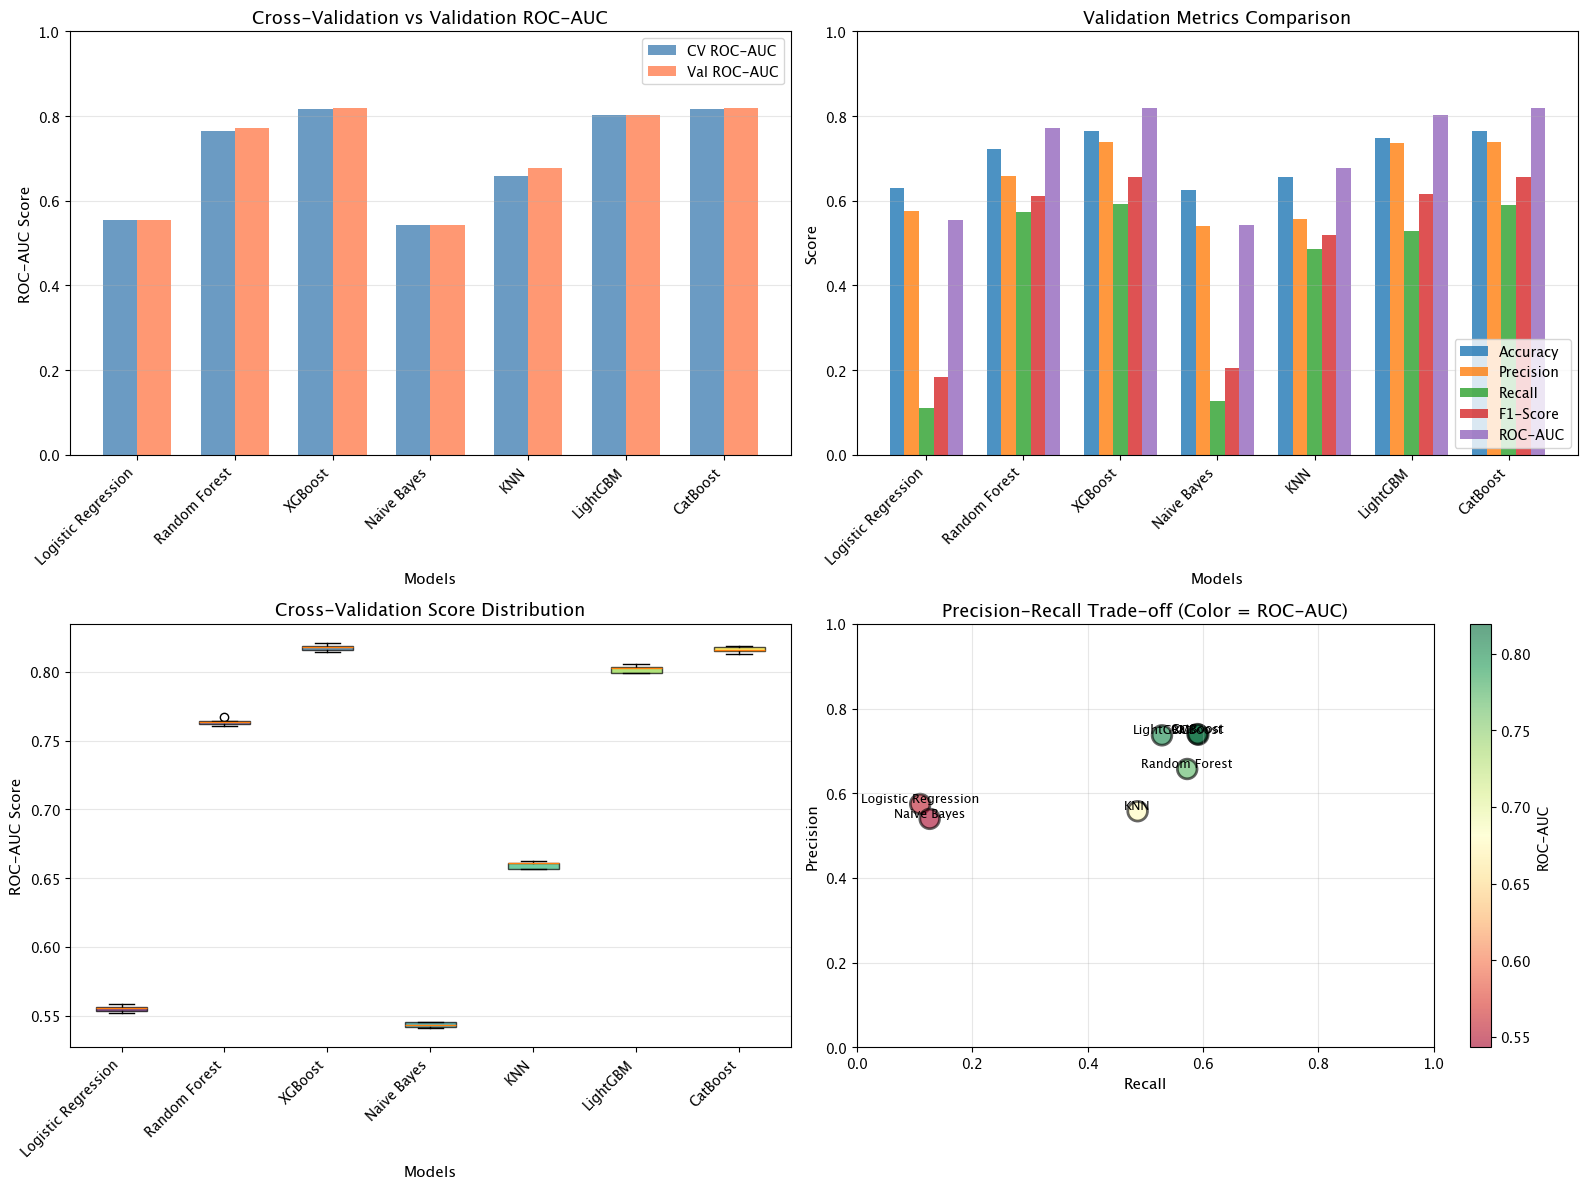

✅ Visualizations generated successfully!


In [26]:
print("📈 === VISUALIZING MODEL PERFORMANCE ===\n")

# Create subplots for comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROC-AUC Comparison (CV vs Validation)
ax1 = axes[0, 0]
model_names = list(models.keys())
cv_aucs = [cv_results[m]['mean'] for m in model_names]
val_aucs = [val_results[m]['roc_auc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax1.bar(x - width/2, cv_aucs, width, label='CV ROC-AUC', alpha=0.8, color='steelblue')
bars2 = ax1.bar(x + width/2, val_aucs, width, label='Val ROC-AUC', alpha=0.8, color='coral')

ax1.set_xlabel('Models', fontsize=11, fontweight='bold')
ax1.set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
ax1.set_title('Cross-Validation vs Validation ROC-AUC', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# 2. Validation Metrics Comparison
ax2 = axes[0, 1]
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# Create a grouped bar chart
x = np.arange(len(model_names))
width = 0.15

for i, metric in enumerate(metrics):
    values = [val_results[m][metric] for m in model_names]
    ax2.bar(x + i*width, values, width, label=metric_labels[i], alpha=0.8)

ax2.set_xlabel('Models', fontsize=11, fontweight='bold')
ax2.set_ylabel('Score', fontsize=11, fontweight='bold')
ax2.set_title('Validation Metrics Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x + width * 2)
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.legend(loc='lower right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1])

# 3. Cross-Validation Score Distribution (Box Plot)
ax3 = axes[1, 0]
cv_data = [cv_results[m]['scores'] for m in model_names]
bp = ax3.boxplot(cv_data, labels=model_names, patch_artist=True)

# Color the boxes
colors = plt.cm.viridis(np.linspace(0, 1, len(model_names)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_xlabel('Models', fontsize=11, fontweight='bold')
ax3.set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
ax3.set_title('Cross-Validation Score Distribution', fontsize=13, fontweight='bold')
ax3.set_xticklabels(model_names, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# 4. Precision-Recall Trade-off
ax4 = axes[1, 1]
precisions = [val_results[m]['precision'] for m in model_names]
recalls = [val_results[m]['recall'] for m in model_names]

scatter = ax4.scatter(recalls, precisions, s=200, c=val_aucs, cmap='RdYlGn', 
                     alpha=0.6, edgecolors='black', linewidth=2)

# Add model labels
for i, model_name in enumerate(model_names):
    ax4.annotate(model_name, (recalls[i], precisions[i]), 
                fontsize=9, ha='center', va='bottom')

ax4.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax4.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax4.set_title('Precision-Recall Trade-off (Color = ROC-AUC)', fontsize=13, fontweight='bold')
ax4.grid(alpha=0.3)
ax4.set_xlim([0, 1])
ax4.set_ylim([0, 1])

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('ROC-AUC', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Visualizations generated successfully!")

🎯 === ROC CURVES FOR ALL MODELS ===



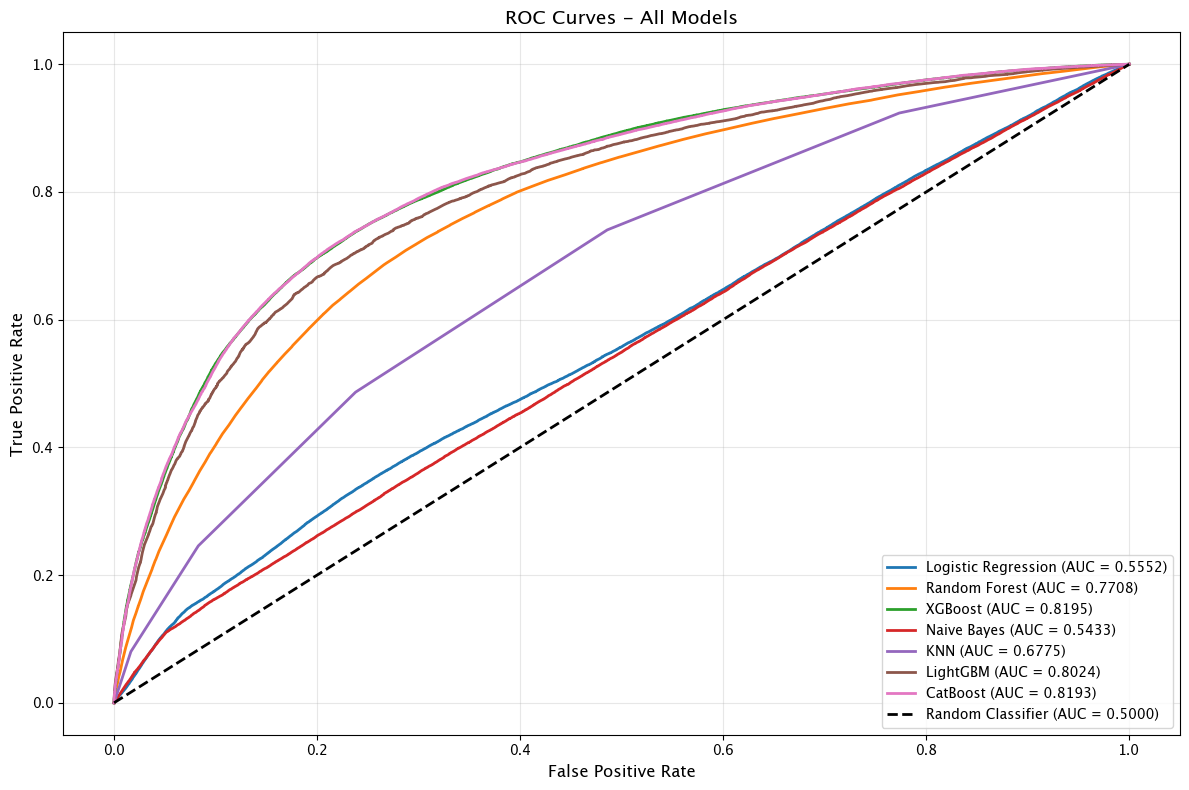

✅ ROC curves plotted successfully!


In [27]:
print("🎯 === ROC CURVES FOR ALL MODELS ===\n")

# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for model_name in models.keys():
    y_prob = val_results[model_name]['probabilities']
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc_score = val_results[model_name]['roc_auc']
    
    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc_score:.4f})')

# Plot diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5000)')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ ROC curves plotted successfully!")

🔍 === CONFUSION MATRICES (All Models) ===



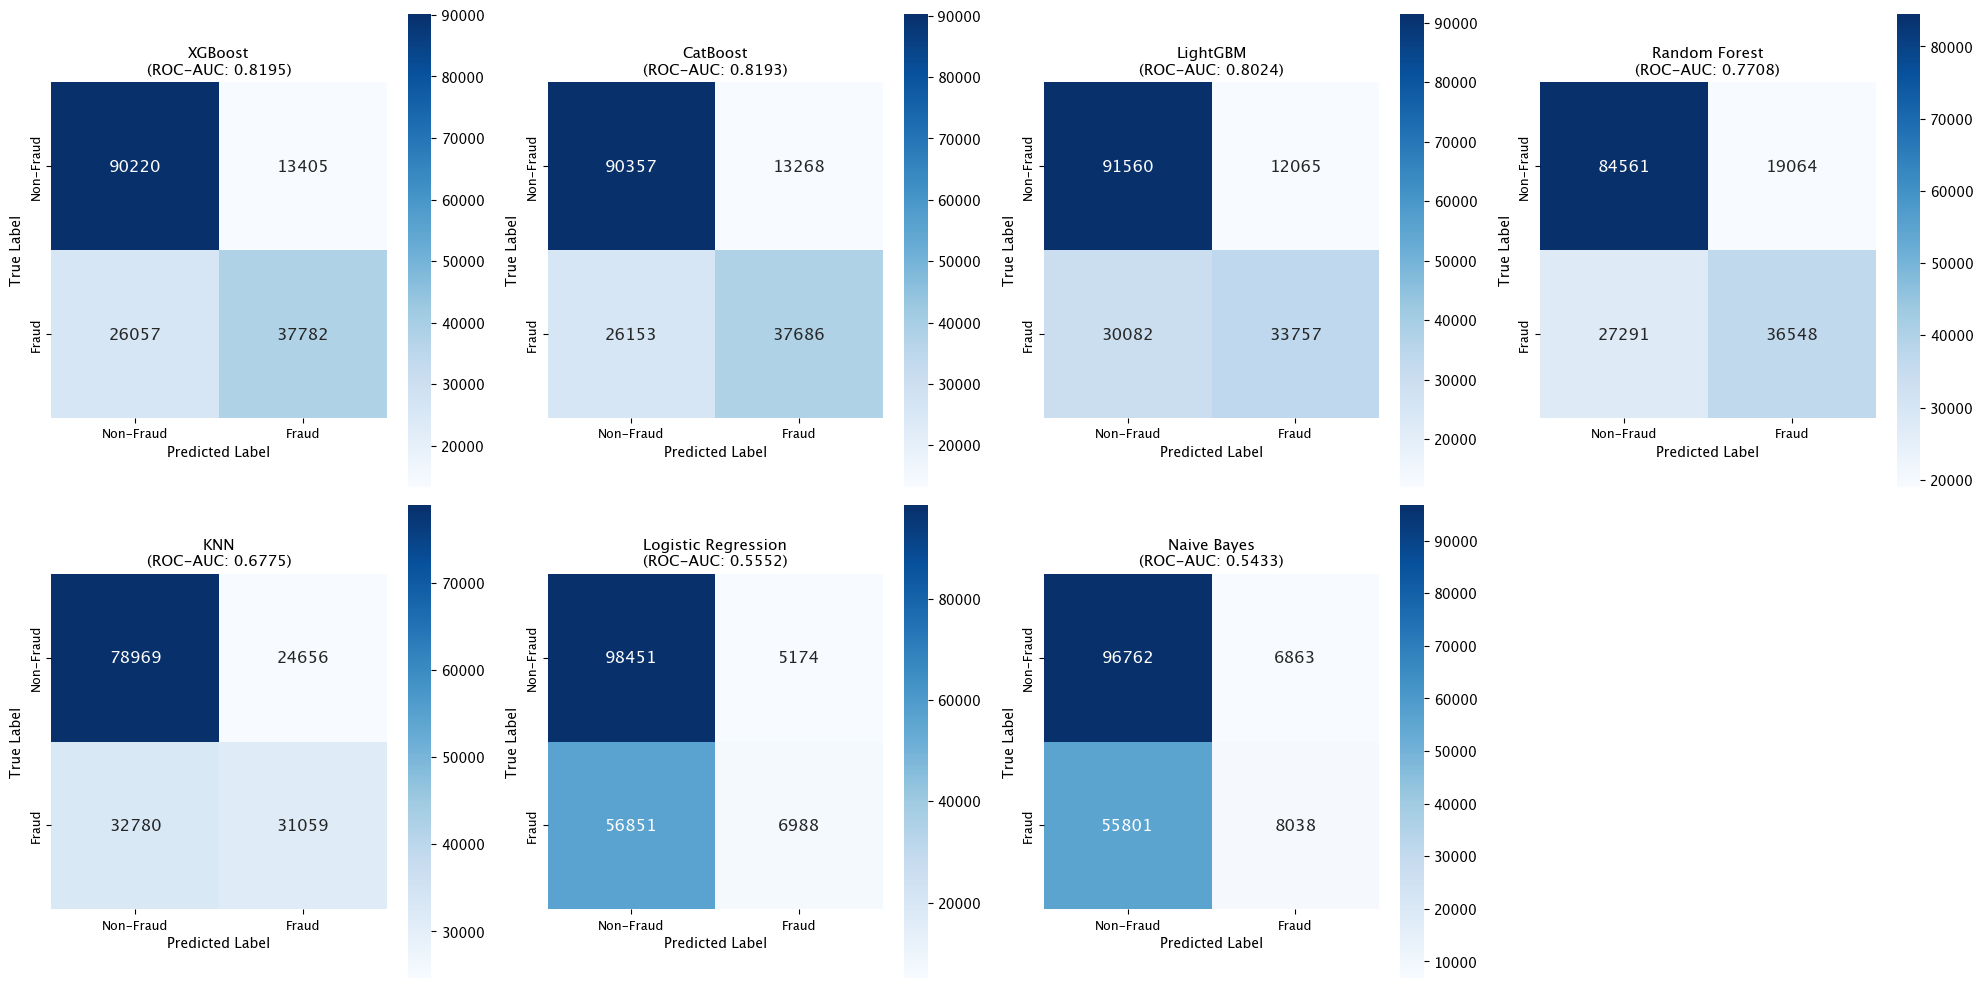

✅ Confusion matrices displayed for all 7 models!


In [28]:
print("🔍 === CONFUSION MATRICES (All Models) ===\n")

# Get all models sorted by validation ROC-AUC
all_models = results_df['Model'].tolist()
n_models = len(all_models)

# Create subplots with 2 rows and 4 columns to fit all 7 models
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()  # Flatten to make indexing easier

for idx, model_name in enumerate(all_models):
    y_pred = val_results[model_name]['predictions']
    cm = confusion_matrix(y_val, y_pred)
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                ax=axes[idx], cbar=True, square=True,
                annot_kws={'size': 12, 'weight': 'bold'})
    
    axes[idx].set_title(f'{model_name}\n(ROC-AUC: {val_results[model_name]["roc_auc"]:.4f})', 
                       fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
    axes[idx].set_xticklabels(['Non-Fraud', 'Fraud'], fontsize=9)
    axes[idx].set_yticklabels(['Non-Fraud', 'Fraud'], fontsize=9)

# Hide the last empty subplot (8th position)
axes[-1].axis('off')

plt.tight_layout()
plt.show()

print(f"✅ Confusion matrices displayed for all {n_models} models!")

In [29]:
print("💾 === SAVING RESULTS AND MODELS ===\n")

# Create directories if they don't exist
Path("models").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

# Save results DataFrame
results_df.to_csv("results/baseline_model_results.csv", index=False)
print("✅ Results saved to: results/baseline_model_results.csv")

# Save the best model
best_model = val_results[best_model_name]['model']
model_filename = f"models/best_baseline_model_{best_model_name.replace(' ', '_').lower()}.pkl"
joblib.dump(best_model, model_filename)
print(f"✅ Best model ({best_model_name}) saved to: {model_filename}")

# Save all models
for model_name, result in val_results.items():
    model_filename = f"models/baseline_{model_name.replace(' ', '_').lower()}.pkl"
    joblib.dump(result['model'], model_filename)
    
print(f"\n✅ All {len(models)} models saved to 'models/' directory")

# Create a detailed results summary
detailed_summary = []
for model_name in models.keys():
    detailed_summary.append({
        'Model': model_name,
        'CV_Mean': cv_results[model_name]['mean'],
        'CV_Std': cv_results[model_name]['std'],
        'CV_Fold_1': cv_results[model_name]['scores'][0],
        'CV_Fold_2': cv_results[model_name]['scores'][1],
        'CV_Fold_3': cv_results[model_name]['scores'][2],
        'CV_Fold_4': cv_results[model_name]['scores'][3],
        'CV_Fold_5': cv_results[model_name]['scores'][4],
        'Val_Accuracy': val_results[model_name]['accuracy'],
        'Val_Precision': val_results[model_name]['precision'],
        'Val_Recall': val_results[model_name]['recall'],
        'Val_F1': val_results[model_name]['f1'],
        'Val_ROC_AUC': val_results[model_name]['roc_auc']
    })

detailed_df = pd.DataFrame(detailed_summary)
detailed_df.to_csv("results/detailed_baseline_results.csv", index=False)
print("✅ Detailed results saved to: results/detailed_baseline_results.csv")

print(f"\n{'='*80}")
print("🎉 BASELINE MODEL TRAINING COMPLETE!")
print(f"{'='*80}")
print(f"\n📊 Summary:")
print(f"   • Total models trained: {len(models)}")
print(f"   • Best performing model: {best_model_name}")
print(f"   • Best validation ROC-AUC: {best_roc_auc:.4f}")
print(f"   • Best validation F1-Score: {val_results[best_model_name]['f1']:.4f}")
print(f"\n🛡️  Data Leakage Prevention:")
print(f"   ✅ Training set: {X_train.shape[0]:,} samples (70%)")
print(f"   ✅ Validation set: {X_val.shape[0]:,} samples (30%)")
print(f"   ✅ Features engineered on training split only")
print(f"   ✅ Scaler fit on training split only")
print(f"   ✅ Physician stats from training split only")
print(f"   ✅ Validation metrics are UNBIASED and RELIABLE")
print(f"\n💡 Next Steps:")
print("   1. Perform hyperparameter tuning on top models")
print("   2. Feature importance analysis")
print("   3. Handle class imbalance (SMOTE, class weights)")
print("   4. Ensemble methods")

💾 === SAVING RESULTS AND MODELS ===

✅ Results saved to: results/baseline_model_results.csv
✅ Best model (XGBoost) saved to: models/best_baseline_model_xgboost.pkl

✅ All 7 models saved to 'models/' directory
✅ Detailed results saved to: results/detailed_baseline_results.csv

🎉 BASELINE MODEL TRAINING COMPLETE!

📊 Summary:
   • Total models trained: 7
   • Best performing model: XGBoost
   • Best validation ROC-AUC: 0.8195
   • Best validation F1-Score: 0.6569

🛡️  Data Leakage Prevention:
   ✅ Training set: 390,747 samples (70%)
   ✅ Validation set: 167,464 samples (30%)
   ✅ Features engineered on training split only
   ✅ Scaler fit on training split only
   ✅ Physician stats from training split only
   ✅ Validation metrics are UNBIASED and RELIABLE

💡 Next Steps:
   1. Perform hyperparameter tuning on top models
   2. Feature importance analysis
   3. Handle class imbalance (SMOTE, class weights)
   4. Ensemble methods
